In [15]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt

env = gym.make('Acrobot-v1', render_mode="human")

In [2]:
# visualizing action space and observation space
print(env.action_space)
print(env.observation_space)
print(env.observation_space.shape)

Discrete(3)
Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
(6,)


In [30]:
class SARSA():
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.bins = 10
        self.Q = {}

    def get_action(self, state):
        rand = np.random.rand()
        if rand < self.epsilon:
            return self.env.action_space.sample()
        else:
            return np.argmax(self.Q.get(state, np.zeros(self.env.action_space.n)))
    
    def bin_state(self, state):
        for i in range(len(state)):
            state[i] = int((state[i] - self.env.observation_space.low[i]) / (self.env.observation_space.high[i] - self.env.observation_space.low[i]) * self.bins)
        return tuple(state)
        
    def update(self, state, action, reward, next_state, next_action):
        if state not in self.Q:
            self.Q[state] = np.zeros(self.env.action_space.n)
        current_q = self.Q[state][action]
        if next_state not in self.Q:
            self.Q[next_state] = np.zeros(self.env.action_space.n)
        next_q = self.Q[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.Q[state][action] = new_q

    def train(self, timesteps=100):
        state, _ = self.env.reset()
        state = self.bin_state(state)
        action = self.get_action(state)
        episode_reward = 0

        with tqdm(total=timesteps) as pbar:
            for t in range(timesteps):
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                next_state = self.bin_state(next_state)
                next_action = self.get_action(next_state)
                self.update(state, action, reward, next_state, next_action)
                done = terminated or truncated
                episode_reward += reward

                if done:
                    pbar.set_postfix({"Reward": episode_reward})
                    state, _ = self.env.reset()
                    state = self.bin_state(state)
                    action = self.get_action(state)
                    episode_reward = 0
                else:
                    state = next_state
                    action = next_action

                pbar.update(1)

        with open(f"sarsa_qtable_{t}.pkl", "wb") as f:
            pickle.dump(self.Q, f)  

    def test(self, qtable_path="sarsa_qtable.pkl", timesteps=1000):
        with open(qtable_path, "rb") as f:
            self.Q = pickle.load(f)
        state, _ = self.env.reset()
        state = self.bin_state(state)
        done = False
        total_reward = 0
        episode_rewards = []
        r = 0

        for t in range(timesteps):

            action = np.argmax(self.Q.get(state, np.zeros(self.env.action_space.n)))
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            next_state = self.bin_state(next_state)
            total_reward += reward
            r += reward
            done = terminated or truncated
            state = next_state

            if done:
                episode_rewards.append(r)
                r = 0
                state, _ = self.env.reset()
                state = self.bin_state(state)
            else:
                state = next_state

        print("Total Reward:", total_reward)
        print("Episode Rewards:", episode_rewards)

In [4]:
# with logging

class SARSA():
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.bins = 10
        self.Q = {}

    def get_action(self, state):
        rand = np.random.rand()
        if rand < self.epsilon:
            return self.env.action_space.sample()
        else:
            if state not in self.Q:
                return self.env.action_space.sample()
            else:
                return np.argmax(self.Q.get(state))
    
    def bin_state(self, state):
        for i in range(len(state)):
            state[i] = int((state[i] - self.env.observation_space.low[i]) / (self.env.observation_space.high[i] - self.env.observation_space.low[i]) * self.bins)
        return tuple(state)
        
    def update(self, state, action, reward, next_state, next_action):
        if state not in self.Q:
            self.Q[state] = np.zeros(self.env.action_space.n)
        current_q = self.Q[state][action]
        if next_state not in self.Q:
            self.Q[next_state] = np.zeros(self.env.action_space.n)
        next_q = self.Q[next_state][next_action]
        td_error = reward + self.gamma * next_q - current_q
        new_q = current_q + self.alpha * td_error
        self.Q[state][action] = new_q
        return td_error

    def train(self, timesteps=100000):
        state, _ = self.env.reset()
        state = self.bin_state(state)
        action = self.get_action(state)

        episode_reward = 0
        episode = 0
        reward_history = []
        td_errors = []

        logs = {
            "step": [],
            "episode": [],
            "episode_reward": [],
            "avg_reward_50": [],
            "avg_td_error": [],
            "epsilon": [],
            "alpha": [],
            "gamma": [],
            "q_size": []
        }

        with tqdm(total=timesteps) as pbar:
            for t in range(1, timesteps + 1):
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                next_state = self.bin_state(next_state)
                next_action = self.get_action(next_state)

                td_error = self.update(state, action, reward, next_state, next_action)
                td_errors.append(abs(td_error))

                done = terminated or truncated
                episode_reward += reward

                if done:
                    episode += 1
                    reward_history.append(episode_reward)
                    avg_reward = np.mean(reward_history[-50:]) if len(reward_history) >= 50 else np.mean(reward_history)
                    avg_td = np.mean(td_errors) if td_errors else 0

                    logs["step"].append(t)
                    logs["episode"].append(episode)
                    logs["episode_reward"].append(episode_reward)
                    logs["avg_reward_50"].append(avg_reward)
                    logs["avg_td_error"].append(avg_td)
                    logs["epsilon"].append(self.epsilon)
                    logs["alpha"].append(self.alpha)
                    logs["gamma"].append(self.gamma)
                    logs["q_size"].append(len(self.Q))

                    pbar.set_postfix({
                        "Ep": episode,
                        "Reward": episode_reward,
                        "Avg50": round(avg_reward, 2),
                        "Qsize": len(self.Q)
                    })

                    td_errors = []
                    episode_reward = 0
                    state, _ = self.env.reset()
                    state = self.bin_state(state)
                    action = self.get_action(state)
                else:
                    state = next_state
                    action = next_action

                pbar.update(1)

        with open(f"sarsa_qtable_{timesteps}.pkl", "wb") as f:
            pickle.dump(self.Q, f)

        with open(f"sarsa_training_logs_{timesteps}.pkl", "wb") as f:
            pickle.dump(logs, f)

    def test(self, qtable_path="sarsa_qtable.pkl", timesteps=1000):
        with open(qtable_path, "rb") as f:
            self.Q = pickle.load(f)

        state, _ = self.env.reset()
        state = self.bin_state(state)

        total_reward = 0
        episode_rewards = []
        r = 0

        for t in range(timesteps):
            action = np.argmax(self.Q.get(state, np.zeros(self.env.action_space.n)))
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            next_state = self.bin_state(next_state)

            total_reward += reward
            r += reward
            done = terminated or truncated

            if done:
                episode_rewards.append(r)
                r = 0
                state, _ = self.env.reset()
                state = self.bin_state(state)
            else:
                state = next_state

        print("Total Reward:", total_reward)
        print("Episode Rewards:", episode_rewards)

In [38]:
sarsa_agent = SARSA(env)
sarsa_agent.train(timesteps=100000)

100%|██████████| 100000/100000 [3:01:22<00:00,  9.19it/s, Ep=207, Reward=-451, Avg50=-462, Qsize=4022] 


In [12]:
sarsa_agent = SARSA(env)
sarsa_agent.test(qtable_path="sarsa_qtable_100000.pkl", timesteps=1000)

Total Reward: -999.0
Episode Rewards: [-366.0, -500.0]


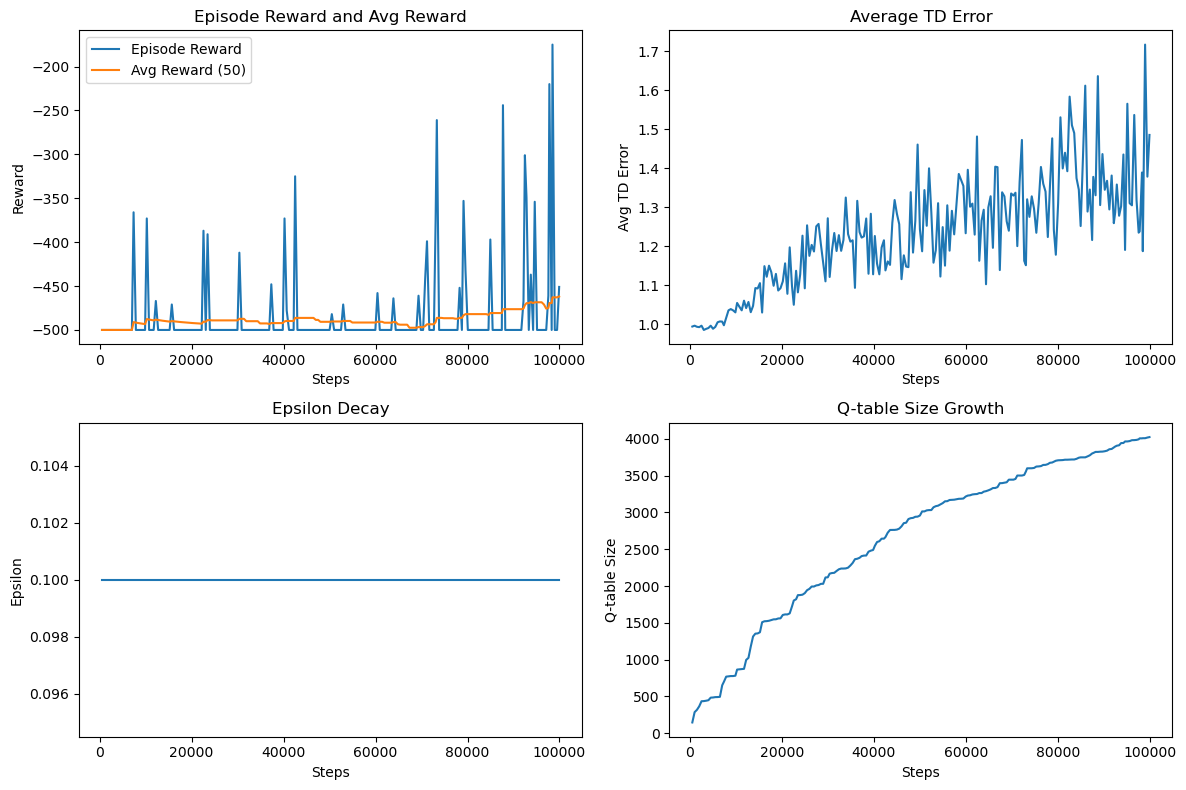

In [16]:
def plot_analysis(logfile, verbose):
    with open(logfile, "rb") as f:
        logs = pickle.load(f)

    plt.figure(figsize=(12, 8))
    plt.subplot(2, 2, 1)
    plt.plot(logs["step"], logs["episode_reward"], label="Episode Reward")
    plt.plot(logs["step"], logs["avg_reward_50"], label="Avg Reward (50)")
    plt.xlabel("Steps")
    plt.ylabel("Reward")
    plt.title("Episode Reward and Avg Reward")
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(logs["step"], logs["avg_td_error"])
    plt.xlabel("Steps")
    plt.ylabel("Avg TD Error")
    plt.title("Average TD Error")

    plt.subplot(2, 2, 3)
    plt.plot(logs["step"], logs["epsilon"])
    plt.xlabel("Steps")
    plt.ylabel("Epsilon")
    plt.title("Epsilon Decay")

    plt.subplot(2, 2, 4)
    plt.plot(logs["step"], logs["q_size"])
    plt.xlabel("Steps")
    plt.ylabel("Q-table Size")
    plt.title("Q-table Size Growth")

    plt.tight_layout()
    if verbose:
        plt.show()

    return logs["episode_reward"], logs["avg_reward_50"], logs["step"]

_, s_ep_rew, s_steps = plot_analysis("sarsa_training_logs_100000.pkl", True)

In [3]:
class QLearn():
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.bins = 10
        self.Q = {}

    def get_action(self, state):
        rand = np.random.rand()
        if rand < self.epsilon:
            return self.env.action_space.sample()
        else:
            return np.argmax(self.Q.get(state, np.zeros(self.env.action_space.n)))
    
    def bin_state(self, state):
        for i in range(len(state)):
            state[i] = int((state[i] - self.env.observation_space.low[i]) / (self.env.observation_space.high[i] - self.env.observation_space.low[i]) * self.bins)
        return tuple(state)
        
    def update(self, state, action, reward, next_state):
        if state not in self.Q:
            self.Q[state] = np.zeros(self.env.action_space.n)
        current_q = self.Q[state][action]
        if next_state not in self.Q:
            self.Q[next_state] = np.zeros(self.env.action_space.n)
            action_max = self.env.action_space.sample()
        else:
            action_max = np.argmax(self.Q[next_state])
        next_q = self.Q[next_state][action_max]
        td_error = reward + self.gamma * next_q - current_q
        new_q = current_q + self.alpha * td_error
        self.Q[state][action] = new_q
        return td_error

    def train(self, timesteps=100000):
        state, _ = self.env.reset()
        state = self.bin_state(state)

        episode_reward = 0
        episode = 0
        reward_history = []
        td_errors = []

        logs = {
            "step": [],
            "episode": [],
            "episode_reward": [],
            "avg_reward_50": [],
            "avg_td_error": [],
            "epsilon": [],
            "alpha": [],
            "gamma": [],
            "q_size": []
        }

        with tqdm(total=timesteps) as pbar:
            for t in range(1, timesteps + 1):
                action = self.get_action(state)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                next_state = self.bin_state(next_state)

                td_error = self.update(state, action, reward, next_state)
                td_errors.append(abs(td_error))

                done = terminated or truncated
                episode_reward += reward

                if done:
                    episode += 1
                    reward_history.append(episode_reward)
                    avg_reward = np.mean(reward_history[-50:]) if len(reward_history) >= 50 else np.mean(reward_history)
                    avg_td = np.mean(td_errors) if td_errors else 0

                    logs["step"].append(t)
                    logs["episode"].append(episode)
                    logs["episode_reward"].append(episode_reward)
                    logs["avg_reward_50"].append(avg_reward)
                    logs["avg_td_error"].append(avg_td)
                    logs["epsilon"].append(self.epsilon)
                    logs["alpha"].append(self.alpha)
                    logs["gamma"].append(self.gamma)
                    logs["q_size"].append(len(self.Q))

                    pbar.set_postfix({
                        "Ep": episode,
                        "Reward": episode_reward,
                        "Avg50": round(avg_reward, 2),
                        "Qsize": len(self.Q)
                    })

                    td_errors = []
                    episode_reward = 0
                    state, _ = self.env.reset()
                    state = self.bin_state(state)
                    action = self.get_action(state)
                else:
                    state = next_state

                pbar.update(1)

        with open(f"qlearn_qtable_{timesteps}.pkl", "wb") as f:
            pickle.dump(self.Q, f)

        with open(f"qlearn_training_logs_{timesteps}.pkl", "wb") as f:
            pickle.dump(logs, f)

    def test(self, qtable_path="qlearn_qtable.pkl", timesteps=1000):
        with open(qtable_path, "rb") as f:
            self.Q = pickle.load(f)

        state, _ = self.env.reset()
        state = self.bin_state(state)

        total_reward = 0
        episode_rewards = []
        r = 0

        for t in range(timesteps):
            action = np.argmax(self.Q.get(state, np.zeros(self.env.action_space.n)))
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            next_state = self.bin_state(next_state)

            total_reward += reward
            r += reward
            done = terminated or truncated

            if done:
                episode_rewards.append(r)
                r = 0
                state, _ = self.env.reset()
                state = self.bin_state(state)
            else:
                state = next_state

        print("Total Reward:", total_reward)
        print("Episode Rewards:", episode_rewards)

In [4]:
q_agent = QLearn(env)
q_agent.train(timesteps=100000)

/Users/maheshgondi/miniconda3/envs/rl_pa1/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
100%|██████████| 100000/100000 [1:53:22<00:00, 14.70it/s, Ep=207, Reward=-500, Avg50=-477, Qsize=4151] 


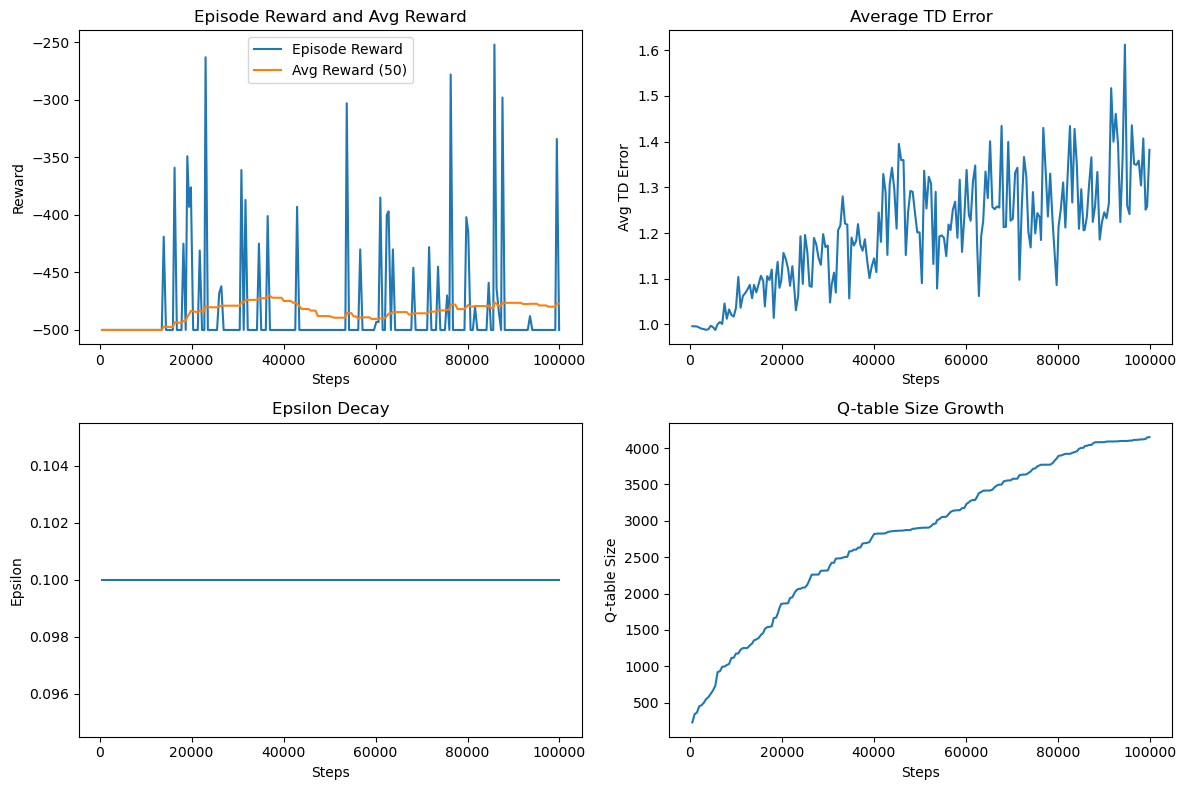

In [17]:
_, q_ep_rew, q_steps = plot_analysis("qlearn_training_logs_100000.pkl", True)

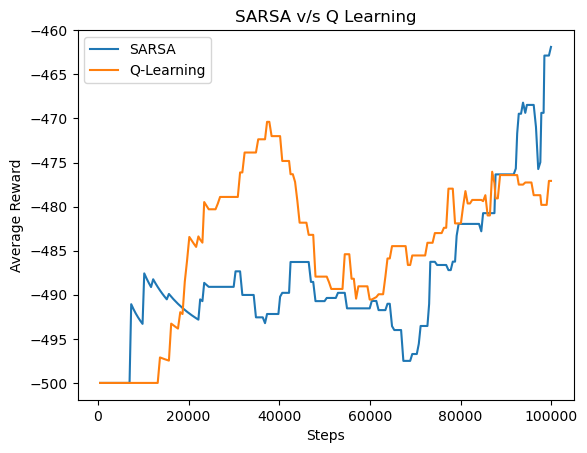

: 

In [ ]:
# comparing sarsa and q learning avg reward over 50 episodes -

plt.plot(s_steps, s_ep_rew, label="SARSA")
plt.plot(s_steps, q_ep_rew, label="Q-Learning")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("SARSA v/s Q Learning")
plt.legend()